In [ ]:
import sys
from pathlib import Path

def _find_scripts_dir():
    start = Path.cwd().resolve()
    for base in (start, *start.parents):
        for cand in (base / "scripts", base,
                     *sorted(base.glob("*/scripts")), *sorted(base.glob("*/*/scripts"))):
            if (cand / "project_paths.py").is_file():
                return cand
    raise FileNotFoundError(
        "scripts/project_paths.py not found. Open this notebook from inside the "
        "cloned repository, or point the kernel's working directory at it."
    )

sys.path.insert(0, str(_find_scripts_dir()))
from project_config import *
import numpy as np, pandas as pd
model_df = load_model_df()
y = model_df["phq9"]
assert len(ACOUSTIC) == 72

In [3]:
# Standardizing the numerical features

from sklearn.preprocessing import StandardScaler
X_demo = model_df[DEMO]
Xz_demo= pd.DataFrame(StandardScaler().fit_transform(X_demo), columns=X_demo.columns, index=X_demo.index)

X_psych = model_df[PSYCH]
Xz_psych= pd.DataFrame(StandardScaler().fit_transform(X_psych), columns=X_psych.columns, index=X_psych.index)

X_clinical = model_df[CLINICAL]
Xz_clinical= pd.DataFrame(StandardScaler().fit_transform(X_clinical), columns=X_clinical.columns, index=X_clinical.index)

In [4]:
# coefficients for linear baseline
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression


y = model_df["phq9"]
lin = LinearRegression()
lin.fit(Xz_psych, y)
coef = pd.Series(lin.coef_, index=X_psych.columns).sort_values(key=np.abs, ascending=False)
print(f"Intercept: {lin.intercept_:.3f}")
print("Coefficients:")
print(coef)


Intercept: 9.404
Coefficients:
gad7      4.778936
PSQI      2.311755
SSRS     -1.624121
ctq_sf    0.625340
LES       0.513192
dtype: float64


In [5]:
# coefficients for Random Forest baseline (demographic values)
import pandas as pd
from sklearn.ensemble import RandomForestRegressor


y = model_df["phq9"]
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_demo, y)
coef = pd.Series(rf.feature_importances_, index=X_demo.columns).sort_values(ascending=False)
print("Feature Importances:")
print(coef)

Feature Importances:
age                0.479096
education_years    0.426805
gender             0.094098
dtype: float64


In [6]:
# Computing permutation importance for the Random Forest model (demographic values)
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X_demo, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# built in feature importance
mdi = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
print("MDI Feature Importances: ", mdi)

# permutation importance on test set
result = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, scoring='r2')

perm_imp= pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)
perm_std= pd.Series(result.importances_std, index=X_test.columns).loc[perm_imp.index]

print("Permutation Importances: ", perm_imp)
print("Standard Deviations: ", perm_std)

MDI Feature Importances:  age                0.510167
education_years    0.398915
gender             0.090918
dtype: float64
Permutation Importances:  education_years    1.018335
age                0.267131
gender             0.049465
dtype: float64
Standard Deviations:  education_years    0.491660
age                0.257432
gender             0.076392
dtype: float64



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Program Files\Python311\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Program Files\Python311\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Program Files\Python311\Lib\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io_loop.start()
  File "c:\Program Files\Python311\Lib\s

AttributeError: _ARRAY_API not found

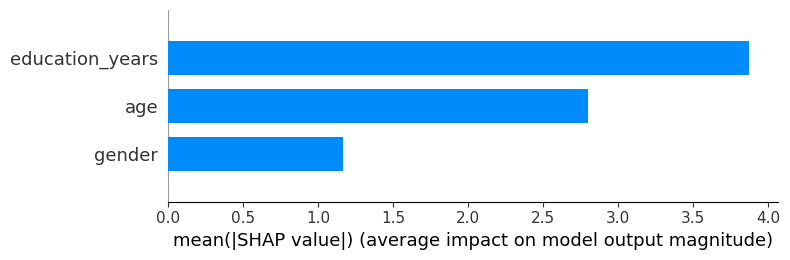

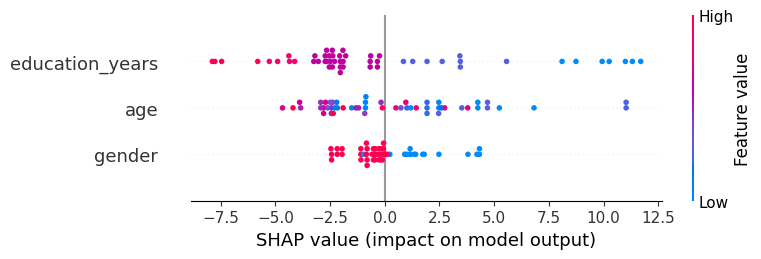

In [7]:
# SHAP for Random Forest model (demo values)
import shap

rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_demo, y)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_demo)

shap.summary_plot(shap_values, X_demo, plot_type="bar") # global ranking
shap.summary_plot(shap_values, X_demo) # beeswarm plot: direction + magnitude

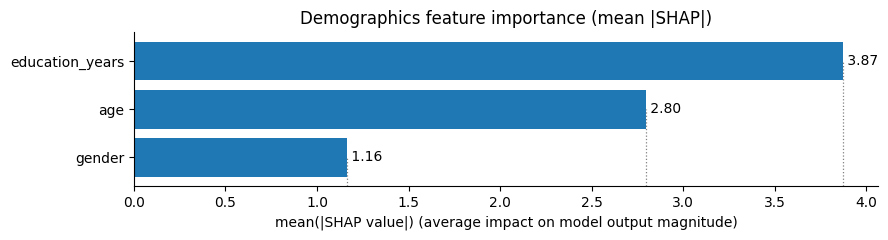

In [8]:
import numpy as np, matplotlib.pyplot as plt, shap
from sklearn.ensemble import RandomForestRegressor

X = X_demo
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
sv = shap.TreeExplainer(rf).shap_values(X)
assert sv.shape[1] == X.shape[1]

mean_abs = np.abs(sv).mean(axis=0)
order = np.argsort(mean_abs)
feats = np.array(X.columns)[order]
vals  = mean_abs[order]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(feats))))
ax.barh(feats, vals, color="#1f77b4")

ymin = -0.6
for i, v in enumerate(vals):
    ax.vlines(v, ymin, i, ls=":", color="gray", lw=0.9)          # vertical dotted line -> x-axis
    ax.text(v, i, f" {v:.2f}", va="center", ha="left", fontsize=10)  # exact value at bar tip
ax.set_ylim(ymin, len(vals) - 0.4)
ax.spines[["top", "right"]].set_visible(False)

# NO set_xticks -> the default scale (0, 1, 2, 3, 4 ...) stays
ax.set_xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
ax.set_title("Demographics feature importance (mean |SHAP|)")
plt.tight_layout()
plt.show()



In [9]:
# coefficients for Random Forest baseline (psych values)
import pandas as pd


y = model_df["phq9"]
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_psych, y)
coef = pd.Series(rf.feature_importances_, index=X_psych.columns).sort_values(ascending=False)
print("Feature Importances:")
print(coef)

Feature Importances:
gad7      0.790197
PSQI      0.131227
SSRS      0.033937
ctq_sf    0.022575
LES       0.022064
dtype: float64


In [10]:
# Computing permutation importance for the Random Forest model (psych values)
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X_psych, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# built in feature importance
mdi = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
print("MDI Feature Importances: ", mdi)

# permutation importance on test set
result = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, scoring='r2')

perm_imp= pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)
perm_std= pd.Series(result.importances_std, index=X_test.columns).loc[perm_imp.index]

print("Permutation Importances: ", perm_imp)
print("Standard Deviations: ", perm_std)

MDI Feature Importances:  gad7      0.775353
PSQI      0.132208
SSRS      0.044161
LES       0.025916
ctq_sf    0.022362
dtype: float64
Permutation Importances:  gad7      0.906574
PSQI      0.068331
LES       0.017793
ctq_sf    0.009205
SSRS     -0.014798
dtype: float64
Standard Deviations:  gad7      0.340548
PSQI      0.035776
LES       0.009659
ctq_sf    0.006565
SSRS      0.024240
dtype: float64


In [11]:
# RF feature importances (MDI): coefficients for Random Forest baseline (clinical values)
import pandas as pd


y = model_df["phq9"]
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_clinical, y)
coef = pd.Series(rf.feature_importances_, index=X_clinical.columns).sort_values(ascending=False)
print("Feature Importances:")
print(coef)

Feature Importances:
gad7               0.775799
PSQI               0.132496
SSRS               0.027870
age                0.024661
LES                0.015182
ctq_sf             0.015051
education_years    0.007308
gender             0.001632
dtype: float64


In [12]:
# Computing permutation importance for the Random Forest model (clinical values)
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X_clinical, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# built in feature importance
mdi = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
print("MDI Feature Importances: ", mdi)

# permutation importance on test set
result = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, scoring='r2')

perm_imp= pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)
perm_std= pd.Series(result.importances_std, index=X_test.columns).loc[perm_imp.index]

print("Permutation Importances: ", perm_imp)
print("Standard Deviations: ", perm_std)

MDI Feature Importances:  gad7               0.769858
PSQI               0.124848
SSRS               0.029668
age                0.023823
LES                0.023114
education_years    0.014816
ctq_sf             0.011475
gender             0.002399
dtype: float64
Permutation Importances:  gad7               0.933113
PSQI               0.054593
LES                0.015627
ctq_sf             0.004119
age                0.002528
gender            -0.001977
education_years   -0.002139
SSRS              -0.017754
dtype: float64
Standard Deviations:  gad7               0.342238
PSQI               0.025895
LES                0.008109
ctq_sf             0.003478
age                0.005485
gender             0.001272
education_years    0.006552
SSRS               0.020868
dtype: float64


In [13]:
import sys
%pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


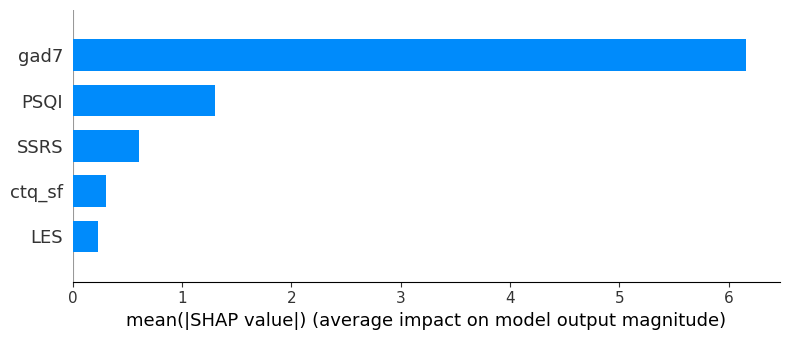

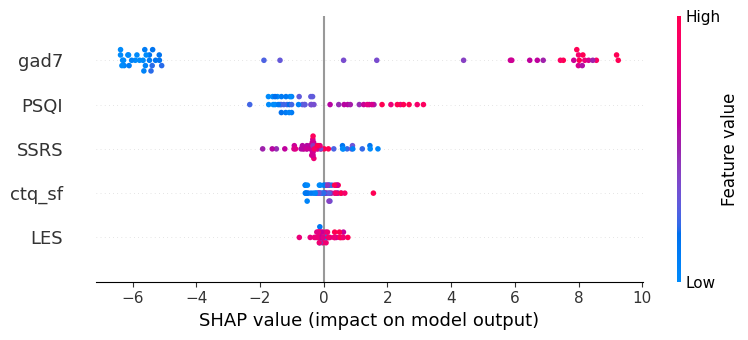

In [14]:
# SHAP for Random Forest model (psych values)
import shap

rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_psych, y)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_psych)

shap.summary_plot(shap_values, X_psych, plot_type="bar") # global ranking
shap.summary_plot(shap_values, X_psych) # beeswarm plot: direction + magnitude

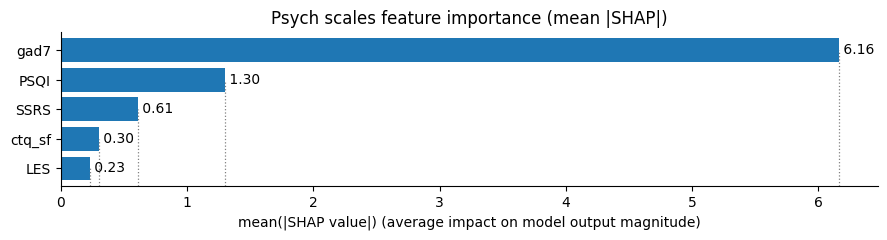

In [15]:
import numpy as np, matplotlib.pyplot as plt, shap
from sklearn.ensemble import RandomForestRegressor

X = model_df[PSYCH] 
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
sv = shap.TreeExplainer(rf).shap_values(X)
assert sv.shape[1] == X.shape[1]

mean_abs = np.abs(sv).mean(axis=0)
order = np.argsort(mean_abs)
feats = np.array(X.columns)[order]
vals  = mean_abs[order]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(feats))))
ax.barh(feats, vals, color="#1f77b4")

ymin = -0.6
for i, v in enumerate(vals):
    ax.vlines(v, ymin, i, ls=":", color="gray", lw=0.9)          # vertical dotted line -> x-axis
    ax.text(v, i, f" {v:.2f}", va="center", ha="left", fontsize=10)  # exact value at bar tip
ax.set_ylim(ymin, len(vals) - 0.4)
ax.spines[["top", "right"]].set_visible(False)

# NO set_xticks -> the default scale (0, 1, 2, 3, 4 ...) stays
ax.set_xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
ax.set_title("Psych scales feature importance (mean |SHAP|)")
plt.tight_layout()
plt.show()


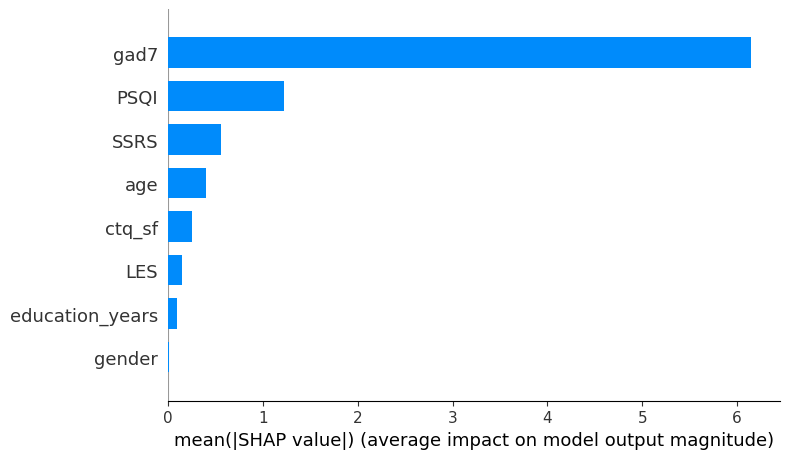

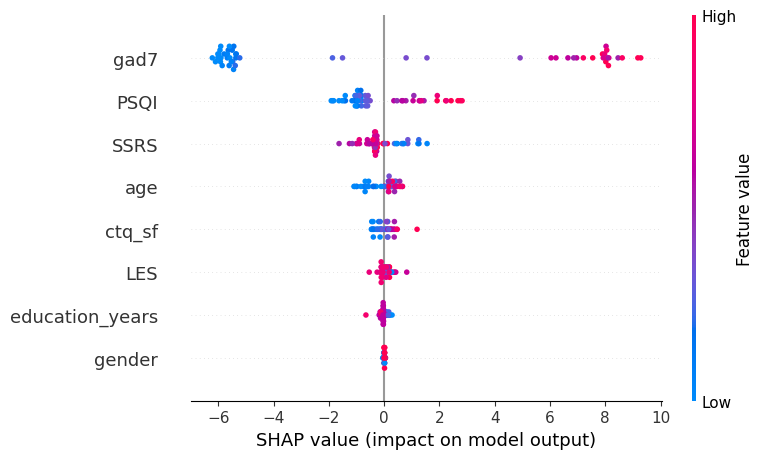

In [16]:
import shap

rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_clinical, y)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_clinical)

shap.summary_plot(shap_values, X_clinical, plot_type="bar") # global ranking
shap.summary_plot(shap_values, X_clinical) # beeswarm plot: direction + magnitude

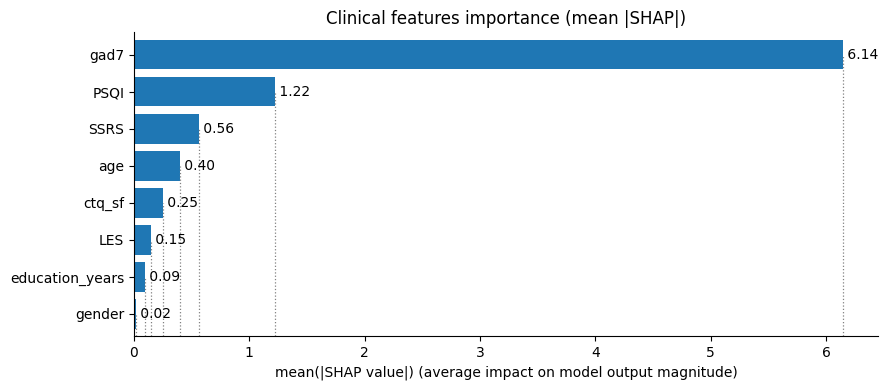

In [17]:
import numpy as np, matplotlib.pyplot as plt, shap
from sklearn.ensemble import RandomForestRegressor

X = model_df[CLINICAL] 
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
sv = shap.TreeExplainer(rf).shap_values(X)
assert sv.shape[1] == X.shape[1]

mean_abs = np.abs(sv).mean(axis=0)
order = np.argsort(mean_abs)
feats = np.array(X.columns)[order]
vals  = mean_abs[order]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(feats))))
ax.barh(feats, vals, color="#1f77b4")

ymin = -0.6
for i, v in enumerate(vals):
    ax.vlines(v, ymin, i, ls=":", color="gray", lw=0.9)          # vertical dotted line -> x-axis
    ax.text(v, i, f" {v:.2f}", va="center", ha="left", fontsize=10)  # exact value at bar tip
ax.set_ylim(ymin, len(vals) - 0.4)
ax.spines[["top", "right"]].set_visible(False)

# NO set_xticks -> the default scale (0, 1, 2, 3, 4 ...) stays
ax.set_xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
ax.set_title("Clinical features importance (mean |SHAP|)")
plt.tight_layout()
plt.show()


In [18]:
# coefficients for acoustic-only Random Forest Model

import pandas as pd
y = model_df["phq9"]
X_acoustic = model_df[ACOUSTIC]
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_acoustic, y)
coef = pd.Series(rf.feature_importances_, index=X_acoustic.columns).sort_values(ascending=False)
print("Feature Importances:")
print(coef)

Feature Importances:
spectralFluxV_sma3nz_amean               0.189361
logRelF0-H1-A3_sma3nz_amean              0.081946
spectralFlux_sma3_amean                  0.066053
alphaRatioV_sma3nz_stddevNorm            0.059523
HNRdBACF_sma3nz_stddevNorm               0.059121
                                           ...   
hammarbergIndexV_sma3nz_amean            0.000587
F2amplitudeLogRelF0_sma3nz_amean         0.000394
spectralFluxV_sma3nz_stddevNorm          0.000308
F3amplitudeLogRelF0_sma3nz_stddevNorm    0.000279
F2frequency_sma3nz_amean                 0.000258
Length: 72, dtype: float64


In [19]:
# Computing permutation importance for the Random Forest model (acoustic values)
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X_acoustic, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# built in feature importance
mdi = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
print("MDI Feature Importances: ", mdi)

# permutation importance on test set
result = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, scoring='r2')

perm_imp= pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)
perm_std= pd.Series(result.importances_std, index=X_test.columns).loc[perm_imp.index]

print("Permutation Importances: ", perm_imp)
print("Standard Deviations: ", perm_std)

MDI Feature Importances:  spectralFluxV_sma3nz_amean               0.249595
equivalentSoundLevel_dBp                 0.046749
logRelF0-H1-A3_sma3nz_amean              0.034015
F1amplitudeLogRelF0_sma3nz_amean         0.032872
F2frequency_sma3nz_stddevNorm            0.032416
                                           ...   
slopeUV500-1500_sma3nz_amean             0.000763
jitterLocal_sma3nz_stddevNorm            0.000618
MeanVoicedSegmentLengthSec               0.000606
F2frequency_sma3nz_amean                 0.000460
F3amplitudeLogRelF0_sma3nz_stddevNorm    0.000415
Length: 72, dtype: float64
Permutation Importances:  spectralFluxV_sma3nz_amean               0.161129
shimmerLocaldB_sma3nz_stddevNorm         0.048054
mfcc3V_sma3nz_stddevNorm                 0.034035
logRelF0-H1-A3_sma3nz_amean              0.023544
logRelF0-H1-H2_sma3nz_stddevNorm         0.014727
                                           ...   
F1amplitudeLogRelF0_sma3nz_stddevNorm   -0.017444
F1amplitudeLogRelF0_s

In [20]:
# MDI + permutation importance for the Random Forest model (top 20 acoustic values)
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = model_df[ACOUSTIC]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_train, y_train)

perm = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=SEED, scoring="r2")

imp = pd.DataFrame({
    "category":  [categorize(c) for c in X.columns],   # <-- links feature to its group
    "mdi":       rf.feature_importances_,
    "perm_mean": perm.importances_mean,
    "perm_std":  perm.importances_std,
}, index=X.columns)

top20 = imp.sort_values("mdi", ascending=False).head(20)
print(top20.round(4).to_string())
top20.to_csv(DATA_DIR / "acoustic_top20_importance.csv")


                                              category     mdi  perm_mean  perm_std
spectralFluxV_sma3nz_amean                    Spectral  0.2496     0.1611    0.1586
equivalentSoundLevel_dBp               Loudness/Energy  0.0467    -0.0021    0.0221
logRelF0-H1-A3_sma3nz_amean              Voice quality  0.0340     0.0235    0.0254
F1amplitudeLogRelF0_sma3nz_amean              Formants  0.0329    -0.0200    0.0265
F2frequency_sma3nz_stddevNorm                 Formants  0.0324    -0.0278    0.0273
mfcc2_sma3_stddevNorm                         Spectral  0.0295    -0.0340    0.0094
alphaRatioV_sma3nz_stddevNorm                 Spectral  0.0278     0.0080    0.0293
F1amplitudeLogRelF0_sma3nz_stddevNorm         Formants  0.0277    -0.0174    0.0175
spectralFlux_sma3_amean                       Spectral  0.0276    -0.0040    0.0154
mfcc3V_sma3nz_stddevNorm                      Spectral  0.0261     0.0340    0.0435
spectralFlux_sma3_stddevNorm                  Spectral  0.0239     0.0011   

In [21]:
# Grouped MDI + permutation importance for the Random Forest model (acoustic values)
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = model_df[ACOUSTIC]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_train, y_train)

# feature -> category map
cat_cols = {}
for feat in X.columns:
    cat_cols.setdefault(categorize(feat), []).append(feat)

mdi = pd.Series(rf.feature_importances_, index=X.columns)   # additive -> sum per category is valid

# grouped permutation importance: shuffle the WHOLE category block together, measure R2 drop
rng = np.random.RandomState(SEED)
baseline = r2_score(y_test, rf.predict(X_test))
N_REPEATS = 30

rows = []
for cat, cols in cat_cols.items():
    drops = []
    for _ in range(N_REPEATS):
        Xp = X_test.copy()
        idx = rng.permutation(len(Xp))
        Xp[cols] = X_test[cols].values[idx]          # same row permutation for all cols -> block shuffle
        drops.append(baseline - r2_score(y_test, rf.predict(Xp)))
    rows.append({
        "category": cat,
        "n_features": len(cols),
        "mdi_sum": round(mdi[cols].sum(), 4),
        "group_perm_mean": round(np.mean(drops), 4),   # R2 drop when the whole category is shuffled
        "group_perm_std":  round(np.std(drops), 4),
    })

by_cat = pd.DataFrame(rows).set_index("category").sort_values("group_perm_mean", ascending=False)
by_cat["mdi_%"] = (100 * by_cat["mdi_sum"] / by_cat["mdi_sum"].sum()).round(1)
print(by_cat.to_string())
by_cat.to_csv(DATA_DIR / "acoustic_importance_by_category.csv")


                 n_features  mdi_sum  group_perm_mean  group_perm_std  mdi_%
category                                                                    
Spectral                 33   0.5861           0.2337          0.2348   58.6
Voice quality            10   0.1225           0.1183          0.0549   12.3
Pitch                     2   0.0221           0.0059          0.0089    2.2
Timing/Pauses             6   0.0183          -0.0070          0.0091    1.8
Loudness/Energy           3   0.0726          -0.0113          0.0382    7.3
Formants                 18   0.1783          -0.0365          0.0586   17.8


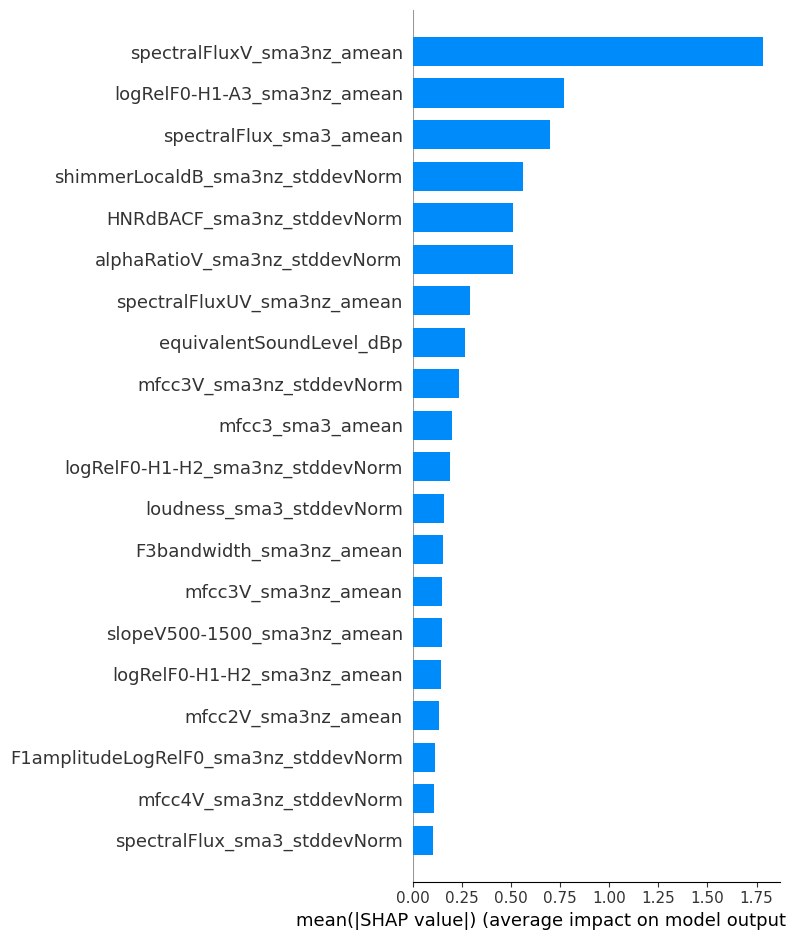

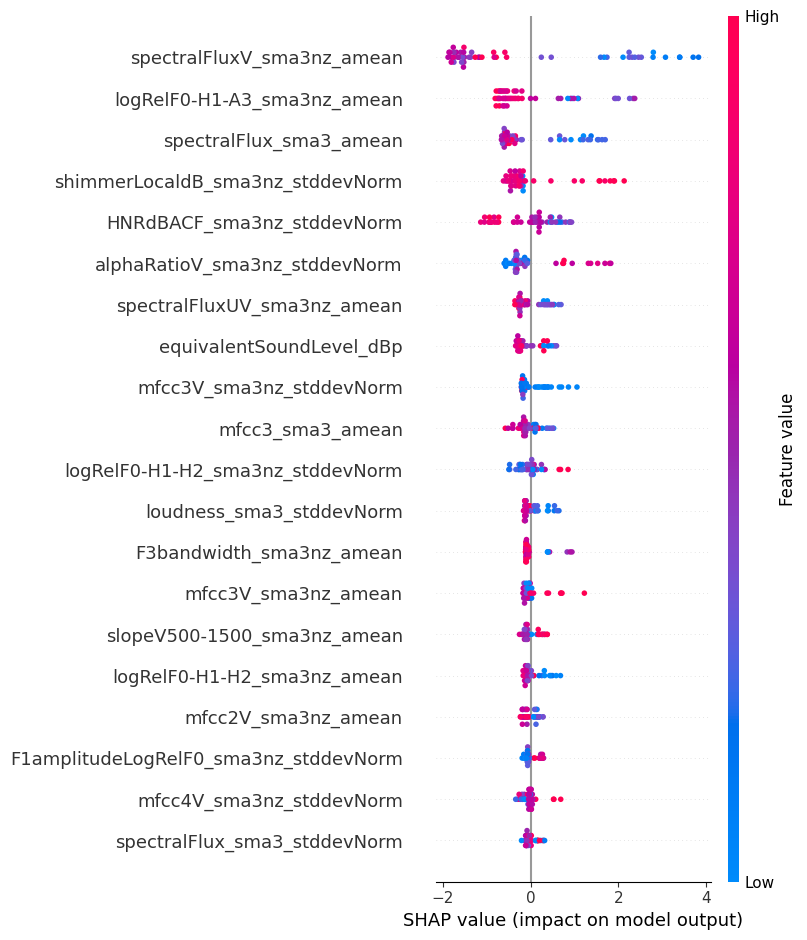

In [22]:
import shap

rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_acoustic, y)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_acoustic)

shap.summary_plot(shap_values, X_acoustic, plot_type="bar") # global ranking
shap.summary_plot(shap_values, X_acoustic) # beeswarm plot: direction + magnitude

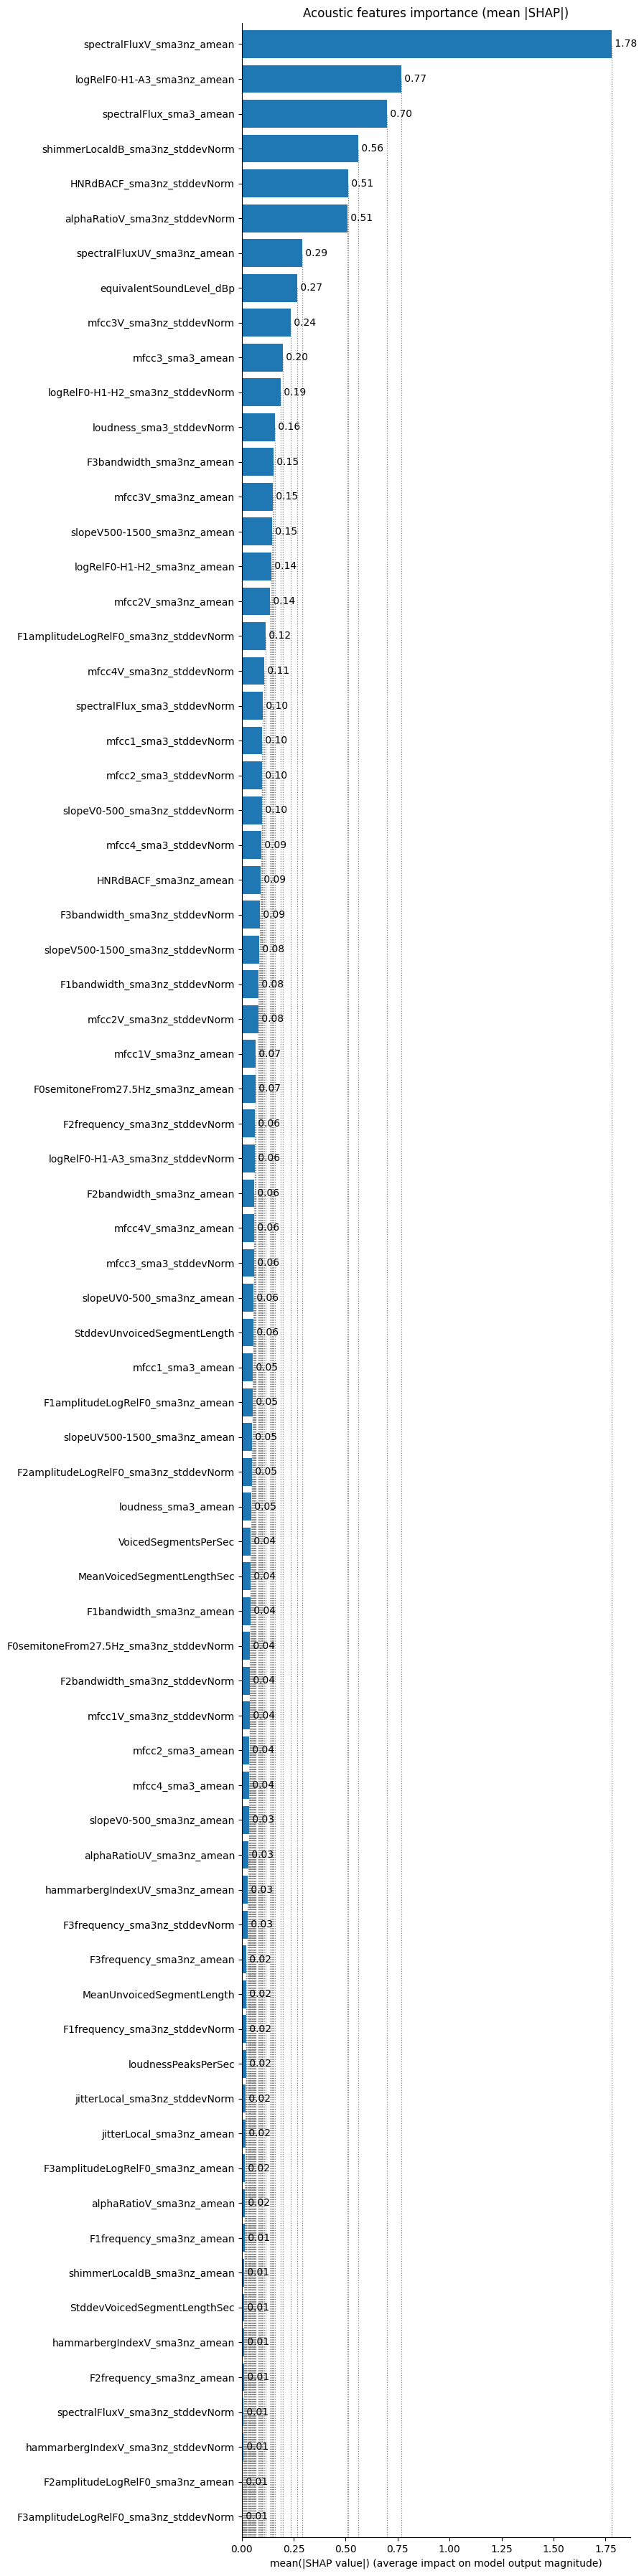

In [23]:
import numpy as np, matplotlib.pyplot as plt, shap
from sklearn.ensemble import RandomForestRegressor

X = model_df[ACOUSTIC] 
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
sv = shap.TreeExplainer(rf).shap_values(X)
assert sv.shape[1] == X.shape[1]

mean_abs = np.abs(sv).mean(axis=0)
order = np.argsort(mean_abs)
feats = np.array(X.columns)[order]
vals  = mean_abs[order]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(feats))))
ax.barh(feats, vals, color="#1f77b4")

ymin = -0.6
for i, v in enumerate(vals):
    ax.vlines(v, ymin, i, ls=":", color="gray", lw=0.9)          # vertical dotted line -> x-axis
    ax.text(v, i, f" {v:.2f}", va="center", ha="left", fontsize=10)  # exact value at bar tip
ax.set_ylim(ymin, len(vals) - 0.4)
ax.spines[["top", "right"]].set_visible(False)

# NO set_xticks -> the default scale (0, 1, 2, 3, 4 ...) stays
ax.set_xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
ax.set_title("Acoustic features importance (mean |SHAP|)")
plt.tight_layout()
plt.show()


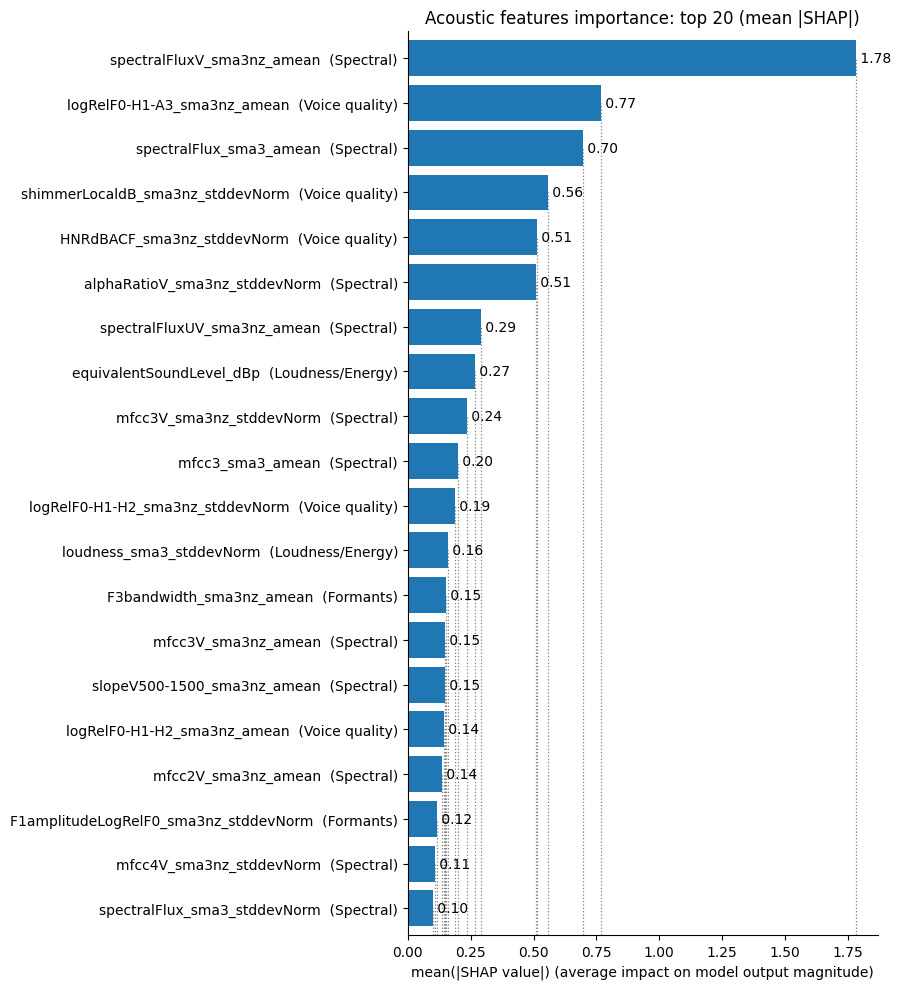

In [24]:
# SHAP plot for top 20 acoustic features (with category appended to labels)
import numpy as np, matplotlib.pyplot as plt, shap
from sklearn.ensemble import RandomForestRegressor

X = model_df[ACOUSTIC]
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
sv = shap.TreeExplainer(rf).shap_values(X)
assert sv.shape[1] == X.shape[1]

mean_abs = np.abs(sv).mean(axis=0)

TOP_N = 20
order = np.argsort(mean_abs)[-TOP_N:]
top_cols = np.array(X.columns)[order]
feats = [f"{c}  ({categorize(c)})" for c in top_cols]   # <-- append category to each label
vals  = mean_abs[order]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(feats))))
ax.barh(feats, vals, color="#1f77b4")

ymin = -0.6
for i, v in enumerate(vals):
    ax.vlines(v, ymin, i, ls=":", color="gray", lw=0.9)
    ax.text(v, i, f" {v:.2f}", va="center", ha="left", fontsize=10)
ax.set_ylim(ymin, len(vals) - 0.4)
ax.spines[["top", "right"]].set_visible(False)

ax.set_xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
ax.set_title(f"Acoustic features importance: top {TOP_N} (mean |SHAP|)")
plt.tight_layout()
plt.show()


In [25]:
# source: the original GeMAPS paper (Eyben et al., 2016)
# Perturbation measures (jitter + shimmer) grouped with HNR under "Voice quality",
# following common practice in affective-speech research.
import numpy as np
import pandas as pd

categories = pd.Series({c: categorize(c) for c in X_acoustic.columns}, name="category")
print(categories.value_counts())          # sanity check: how many features per category

category
Spectral           33
Formants           18
Voice quality      10
Timing/Pauses       6
Loudness/Energy     3
Pitch               2
Name: count, dtype: int64


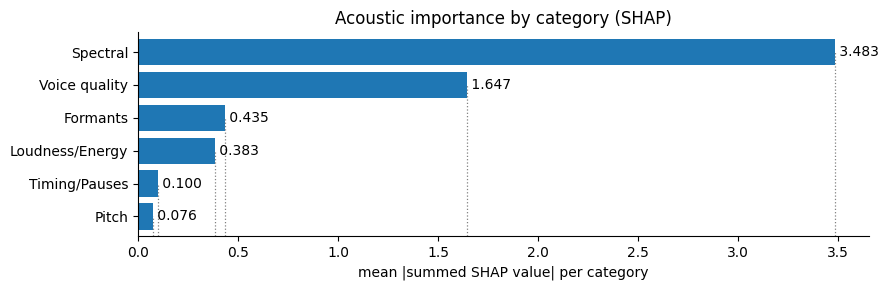

In [26]:
# SHAP values for the Random Forest model (acoustic values) grouped by category
import numpy as np, pandas as pd, matplotlib.pyplot as plt, shap
from sklearn.ensemble import RandomForestRegressor

X = model_df[ACOUSTIC]
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
sv = shap.TreeExplainer(rf).shap_values(X)
assert sv.shape[1] == X.shape[1]

sv_df = pd.DataFrame(sv, columns=X.columns)
cats = pd.Series({c: categorize(c) for c in X.columns})

# Sum SIGNED shap values within each category, per subject first (exact, via additivity)
cat_signed = sv_df.T.groupby(cats).sum().T   # rows = subjects, cols = categories

# THEN take mean absolute value across subjects
by_category = cat_signed.abs().mean(axis=0).sort_values(ascending=False)

names = by_category.index[::-1]        # largest on top
vals  = by_category.values[::-1]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(names))))
ax.barh(names, vals, color="#1f77b4")

ymin = -0.6
for i, v in enumerate(vals):
    ax.vlines(v, ymin, i, ls=":", color="gray", lw=0.9)
    ax.text(v, i, f" {v:.3f}", va="center", ha="left", fontsize=10)
ax.set_ylim(ymin, len(vals) - 0.4)
ax.spines[["top", "right"]].set_visible(False)

ax.set_xlabel("mean |summed SHAP value| per category")
ax.set_title("Acoustic importance by category (SHAP)")
plt.tight_layout()
plt.savefig(FIG_DIR / "shap_acoustic_category_bar.png", dpi=300, bbox_inches="tight")
plt.show()


In [27]:
# RF feature importances (MDI): Demographics + Acoustic
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

demo     = DEMO
clinical = CLINICAL
acoustic = ACOUSTIC
y = model_df["phq9"]

X_demoac = model_df[demo + acoustic]
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_demoac, y)
coef = pd.Series(rf.feature_importances_, index=X_demoac.columns).sort_values(ascending=False)
print("Demographics + Acoustic: Feature Importances (top 15):")
print(coef.head(15))


Demographics + Acoustic: Feature Importances (top 15):
spectralFluxV_sma3nz_amean          0.175935
education_years                     0.089896
logRelF0-H1-A3_sma3nz_amean         0.075485
spectralFlux_sma3_amean             0.065566
HNRdBACF_sma3nz_stddevNorm          0.055899
alphaRatioV_sma3nz_stddevNorm       0.052702
shimmerLocaldB_sma3nz_stddevNorm    0.034630
mfcc3V_sma3nz_stddevNorm            0.024613
equivalentSoundLevel_dBp            0.023632
spectralFluxUV_sma3nz_amean         0.021141
logRelF0-H1-H2_sma3nz_stddevNorm    0.020672
loudness_sma3_stddevNorm            0.017794
mfcc3_sma3_amean                    0.016712
slopeV500-1500_sma3nz_amean         0.016482
mfcc1_sma3_stddevNorm               0.012920
dtype: float64


In [28]:
# Computing permutation importance for the Random Forest model (demo + acoustic values)
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_demoac = pd.concat([X_demo, X_acoustic], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X_demoac, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# built in feature importance
mdi = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
print("MDI Feature Importances: ", mdi)

# permutation importance on test set
result = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, scoring='r2')

perm_imp= pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)
perm_std= pd.Series(result.importances_std, index=X_test.columns).loc[perm_imp.index]

print("Permutation Importances: ", perm_imp)
print("Standard Deviations: ", perm_std)

MDI Feature Importances:  spectralFluxV_sma3nz_amean          0.235661
spectralFlux_sma3_amean             0.039632
F1amplitudeLogRelF0_sma3nz_amean    0.036618
F2frequency_sma3nz_stddevNorm       0.034936
logRelF0-H1-A3_sma3nz_amean         0.034897
                                      ...   
StddevUnvoicedSegmentLength         0.000869
mfcc1_sma3_amean                    0.000774
MeanVoicedSegmentLengthSec          0.000611
MeanUnvoicedSegmentLength           0.000349
gender                              0.000264
Length: 75, dtype: float64
Permutation Importances:  spectralFluxV_sma3nz_amean               0.124205
education_years                          0.054596
mfcc3V_sma3nz_stddevNorm                 0.042028
shimmerLocaldB_sma3nz_stddevNorm         0.039669
logRelF0-H1-A3_sma3nz_amean              0.029345
                                           ...   
F2frequency_sma3nz_stddevNorm           -0.013908
F1amplitudeLogRelF0_sma3nz_amean        -0.014264
mfcc3V_sma3nz_amean       

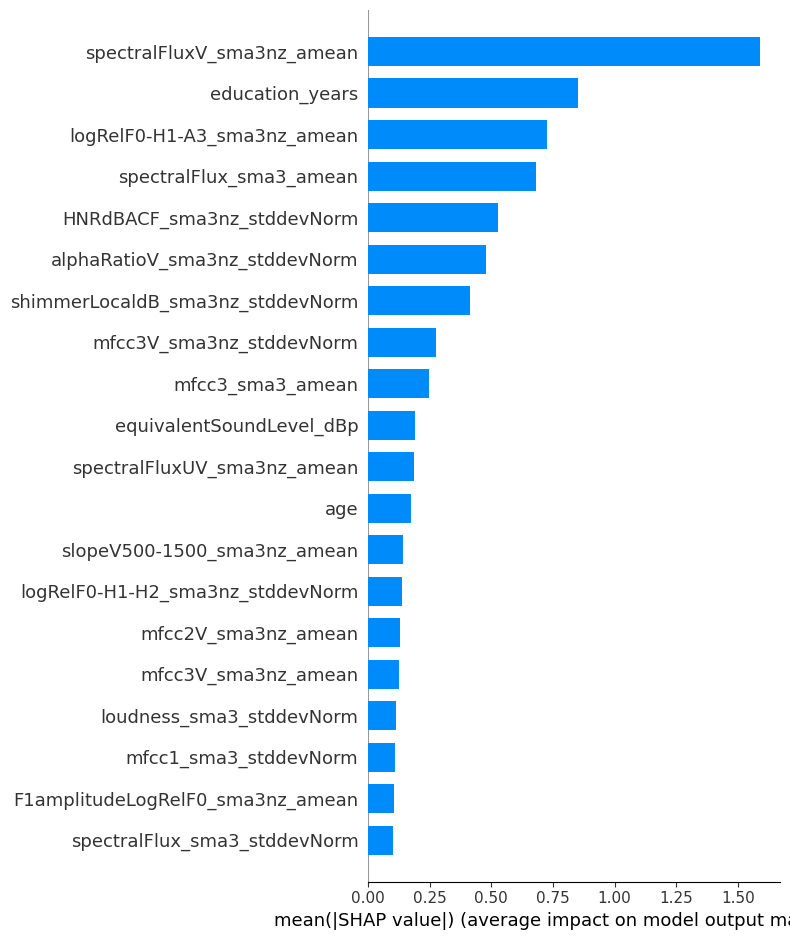

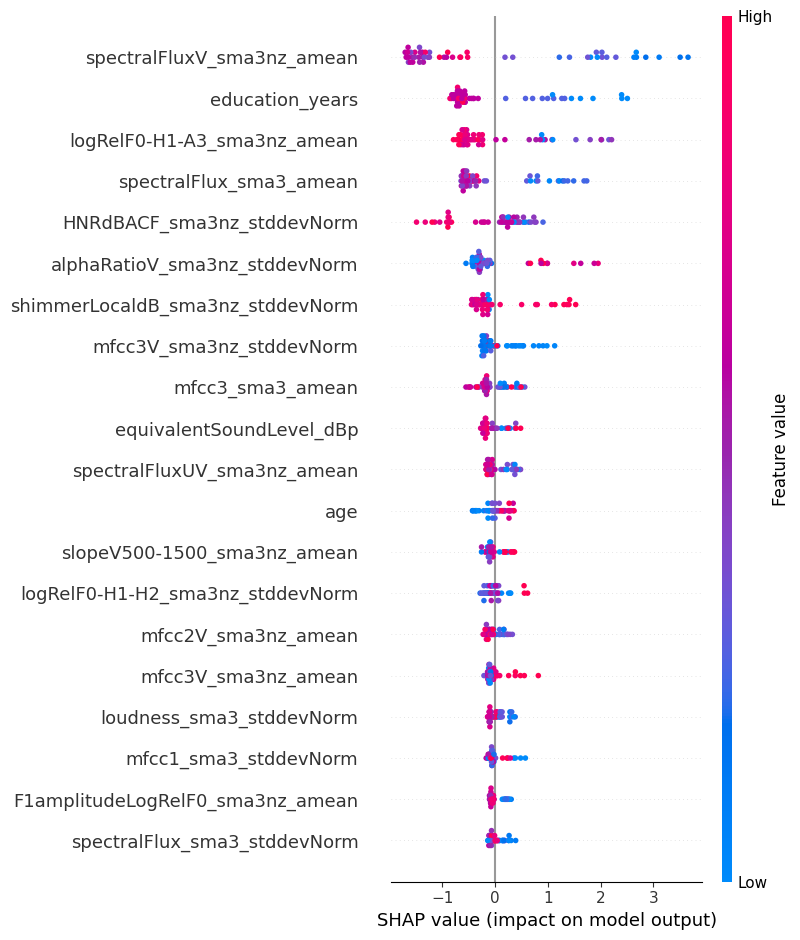

In [29]:
# SHAP for the Demographics + Acoustic Random Forest model
import shap

# Demographics + acoustic: exclude id, target, and the psych scales.
X_demoac = model_df[DEMO_ACOUSTIC]
y = model_df["phq9"]

rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_demoac, y)
explainer = shap.TreeExplainer(rf)
shap_demoac = explainer.shap_values(X_demoac)                       # distinct name, not shap_values

shap.summary_plot(shap_demoac, X_demoac, plot_type="bar", max_display=20)  # global ranking (top 20)
shap.summary_plot(shap_demoac, X_demoac, max_display=20)                    # beeswarm: direction + magnitude


===== Demographics + Acoustic SHAP by category (corrected, additive) =====
                 mean_abs_shap_category  n_features
Spectral                         3.1778          33
Voice quality                    1.4393          10
education_years                  0.8527           1
Formants                         0.3987          18
Loudness/Energy                  0.3035           3
age                              0.1738           1
Timing/Pauses                    0.1177           6
Pitch                            0.0725           2
gender                           0.0004           1


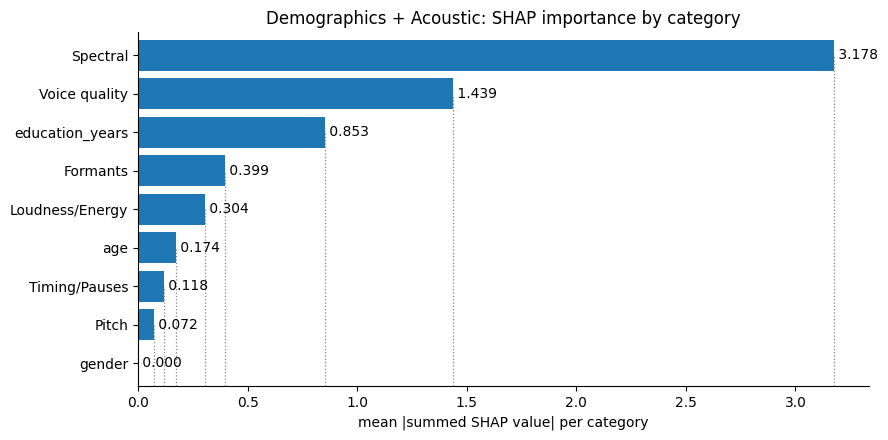

In [30]:
# SHAP for Demographics + Acoustic, aggregated by category
import re, numpy as np, pandas as pd, shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

def build_catmap(cols):
    non_acoustic = {"age", "gender", "education_years", "ctq_sf", "LES", "SSRS", "gad7", "PSQI"}
    return {c: (c if c in non_acoustic else categorize(c)) for c in cols}

def shap_by_category(name, X, y):
    rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
    shap_vals = shap.TreeExplainer(rf).shap_values(X)
    shap_df = pd.DataFrame(shap_vals, columns=X.columns)

    cat = pd.Series(build_catmap(X.columns))
    cat_signed = shap_df.T.groupby(cat).sum().T          # signed sum per subject (additive)
    by_cat = cat_signed.abs().mean(axis=0).sort_values(ascending=False)  # then mean |·|

    tbl = pd.DataFrame({
        "mean_abs_shap_category": by_cat.round(4),
        "n_features": cat.value_counts().reindex(by_cat.index),
    })
    print(f"\n===== {name} SHAP by category (corrected, additive) =====")
    print(tbl.to_string())

    # --- styled plot ---
    names = by_cat.index[::-1]        # largest on top
    vals  = by_cat.values[::-1]
    fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(names))))
    ax.barh(names, vals, color="#1f77b4")

    ymin = -0.6
    for i, v in enumerate(vals):
        ax.vlines(v, ymin, i, ls=":", color="gray", lw=0.9)
        ax.text(v, i, f" {v:.3f}", va="center", ha="left", fontsize=10)
    ax.set_ylim(ymin, len(vals) - 0.4)
    ax.spines[["top", "right"]].set_visible(False)

    ax.set_xlabel("mean |summed SHAP value| per category")
    ax.set_title(f"{name}: SHAP importance by category")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"shap_{name.lower().replace(' ', '_').replace('+', 'plus')}_category_bar.png",
                dpi=300, bbox_inches="tight")
    plt.show()
    return tbl

# --- run: Demographics + Acoustic ---
y = model_df["phq9"]
tbl_demoac = shap_by_category("Demographics + Acoustic", model_df[DEMO + ACOUSTIC], y)


In [31]:
# RF feature importances (MDI): Clinical + Acoustic
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

X_clinac = model_df[clinical + acoustic]   # reuses clinical/acoustic from cell 1
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_clinac, y)
coef = pd.Series(rf.feature_importances_, index=X_clinac.columns).sort_values(ascending=False)
print("Clinical + Acoustic — Feature Importances (top 15):")
print(coef.head(15))


Clinical + Acoustic — Feature Importances (top 15):
gad7                                0.761015
PSQI                                0.096736
mfcc3_sma3_amean                    0.011464
age                                 0.009364
mfcc4V_sma3nz_amean                 0.006706
hammarbergIndexUV_sma3nz_amean      0.004780
mfcc3V_sma3nz_stddevNorm            0.004746
alphaRatioUV_sma3nz_amean           0.004711
mfcc1_sma3_stddevNorm               0.004480
mfcc2V_sma3nz_stddevNorm            0.004368
mfcc2V_sma3nz_amean                 0.003982
mfcc4_sma3_stddevNorm               0.003754
logRelF0-H1-H2_sma3nz_stddevNorm    0.003433
spectralFlux_sma3_stddevNorm        0.003420
mfcc3V_sma3nz_amean                 0.003351
dtype: float64


In [32]:
# Computing permutation importance for the Random Forest combined model (clinical + acoustic values)
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_combined = pd.concat([X_clinical, X_acoustic], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# built in feature importance
mdi = pd.Series(rf.feature_importances_, index=X_test.columns).sort_values(ascending=False)
print("MDI Feature Importances: ", mdi)

# permutation importance on test set
result = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, scoring='r2')

perm_imp= pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)
perm_std= pd.Series(result.importances_std, index=X_test.columns).loc[perm_imp.index]

print("Permutation Importances: ", perm_imp)
print("Standard Deviations: ", perm_std)

MDI Feature Importances:  gad7                             0.738416
PSQI                             0.093315
spectralFlux_sma3_stddevNorm     0.010000
F1frequency_sma3nz_stddevNorm    0.009718
mfcc2V_sma3nz_stddevNorm         0.009141
                                   ...   
F2bandwidth_sma3nz_stddevNorm    0.000140
StddevUnvoicedSegmentLength      0.000129
logRelF0-H1-H2_sma3nz_amean      0.000115
gender                           0.000109
slopeUV500-1500_sma3nz_amean     0.000092
Length: 80, dtype: float64
Permutation Importances:  gad7                               1.231059
PSQI                               0.034785
mfcc4V_sma3nz_amean                0.004453
F1frequency_sma3nz_stddevNorm      0.003944
mfcc4_sma3_stddevNorm              0.003342
                                     ...   
spectralFlux_sma3_amean           -0.002024
spectralFluxV_sma3nz_amean        -0.002355
spectralFluxV_sma3nz_stddevNorm   -0.002381
jitterLocal_sma3nz_amean          -0.002711
loudness_sma3_amean

In [33]:
# Grouped MDI + permutation importance: Demographics + Acoustic
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = model_df[DEMO + ACOUSTIC]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_train, y_train)

# acoustic -> its category; every non-acoustic (demo) feature stays as itself
cat_cols = {}
for feat in X.columns:
    key = categorize(feat) if feat in ACOUSTIC else feat     # <-- demo features individual
    cat_cols.setdefault(key, []).append(feat)

mdi = pd.Series(rf.feature_importances_, index=X.columns)

rng = np.random.RandomState(SEED)
baseline = r2_score(y_test, rf.predict(X_test))
N_REPEATS = 30

rows = []
for cat, cols in cat_cols.items():
    drops = []
    for _ in range(N_REPEATS):
        Xp = X_test.copy()
        idx = rng.permutation(len(Xp))
        Xp[cols] = X_test[cols].values[idx]          # block shuffle (single feature for demo, group for acoustic)
        drops.append(baseline - r2_score(y_test, rf.predict(Xp)))
    rows.append({
        "category": cat,
        "n_features": len(cols),
        "mdi_sum": round(mdi[cols].sum(), 4),
        "group_perm_mean": round(np.mean(drops), 4),
        "group_perm_std":  round(np.std(drops), 4),
    })

by_cat = pd.DataFrame(rows).set_index("category").sort_values("group_perm_mean", ascending=False)
print(by_cat.to_string())
by_cat.to_csv(DATA_DIR / "demoac_importance_by_category.csv")


                 n_features  mdi_sum  group_perm_mean  group_perm_std
category                                                             
Spectral                 33   0.5537           0.2678          0.1871
Voice quality            10   0.1308           0.1184          0.0655
education_years           1   0.0340           0.0697          0.0299
Loudness/Energy           3   0.0508           0.0046          0.0278
Pitch                     2   0.0180           0.0035          0.0087
age                       1   0.0159           0.0025          0.0061
gender                    1   0.0003          -0.0001          0.0008
Timing/Pauses             6   0.0128          -0.0124          0.0106
Formants                 18   0.1836          -0.0307          0.0548


In [34]:
# Grouped MDI + permutation importance: Clinical + Acoustic (clinical features kept individual)
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = model_df[CLINICAL + ACOUSTIC]                    # <-- clinical (8) + acoustic (72)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_train, y_train)

# acoustic -> its category; every non-acoustic (clinical) feature stays as itself
cat_cols = {}
for feat in X.columns:
    key = categorize(feat) if feat in ACOUSTIC else feat
    cat_cols.setdefault(key, []).append(feat)

mdi = pd.Series(rf.feature_importances_, index=X.columns)

rng = np.random.RandomState(SEED)
baseline = r2_score(y_test, rf.predict(X_test))
N_REPEATS = 30

rows = []
for cat, cols in cat_cols.items():
    drops = []
    for _ in range(N_REPEATS):
        Xp = X_test.copy()
        idx = rng.permutation(len(Xp))
        Xp[cols] = X_test[cols].values[idx]
        drops.append(baseline - r2_score(y_test, rf.predict(Xp)))
    rows.append({
        "category": cat,
        "n_features": len(cols),
        "mdi_sum": round(mdi[cols].sum(), 4),
        "group_perm_mean": round(np.mean(drops), 4),
        "group_perm_std":  round(np.std(drops), 4),
    })

by_cat = pd.DataFrame(rows).set_index("category").sort_values("group_perm_mean", ascending=False)
print(by_cat.to_string())
by_cat.to_csv(DATA_DIR / "clinac_importance_by_category.csv")   # <-- new filename


                 n_features  mdi_sum  group_perm_mean  group_perm_std
category                                                             
gad7                      1   0.7384           1.3534          0.4194
PSQI                      1   0.0933           0.0442          0.0194
Formants                 18   0.0246           0.0043          0.0055
age                       1   0.0056           0.0033          0.0024
LES                       1   0.0024           0.0019          0.0010
education_years           1   0.0015           0.0017          0.0009
ctq_sf                    1   0.0008           0.0007          0.0006
gender                    1   0.0001           0.0002          0.0001
SSRS                      1   0.0007          -0.0002          0.0004
Pitch                     2   0.0056          -0.0005          0.0018
Timing/Pauses             6   0.0071          -0.0010          0.0010
Spectral                 33   0.0919          -0.0013          0.0065
Voice quality       

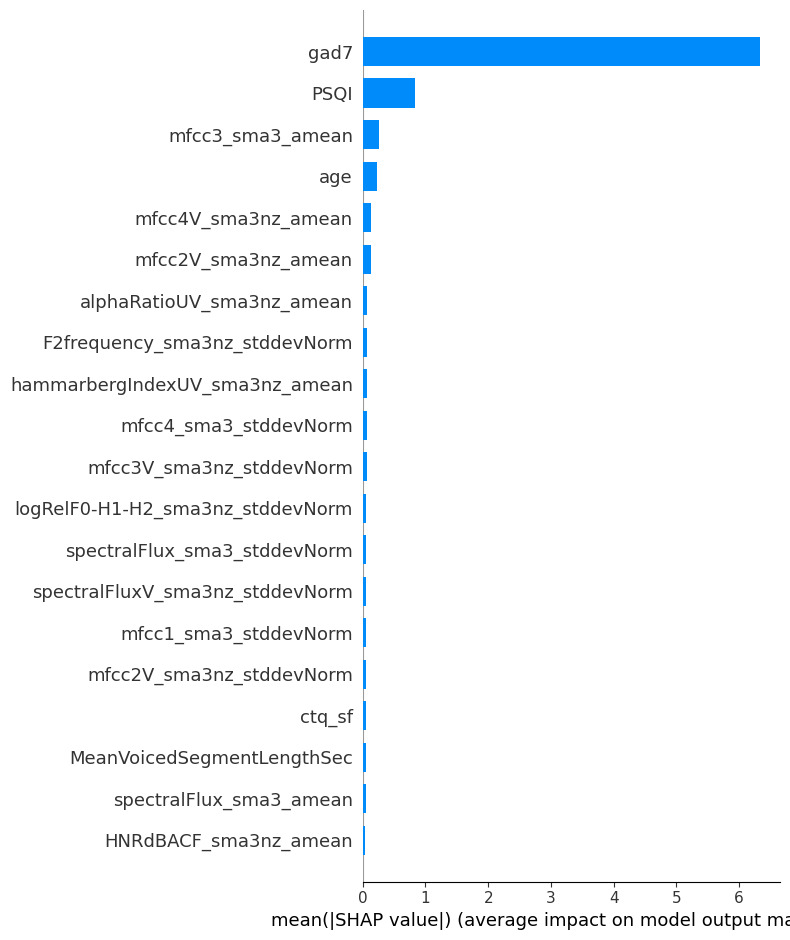

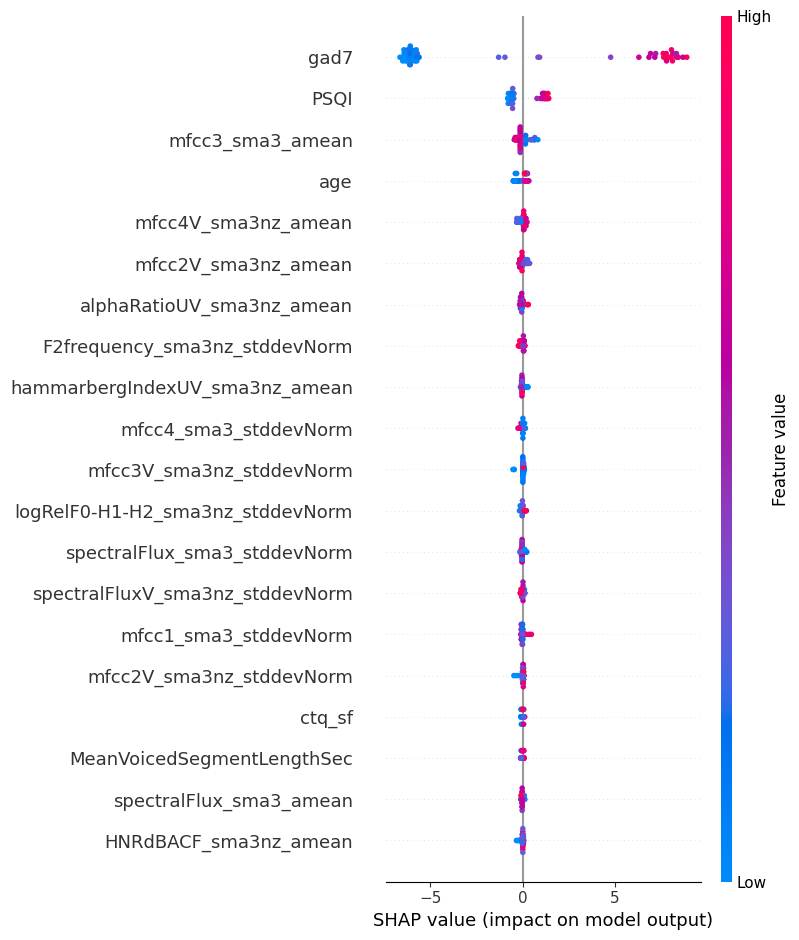

In [35]:
# SHAP for the combined Clinical + Acoustic Random Forest model
import shap

# Combined feature set: everything except the id and the target (clinical + acoustic = 96 features).
X_combined = model_df[CLINICAL_ACOUSTIC]
y = model_df["phq9"]

rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_combined, y)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_combined)

shap.summary_plot(shap_values, X_combined, plot_type="bar", max_display=20)  # global ranking (top 20)
shap.summary_plot(shap_values, X_combined, max_display=20)                    # beeswarm: direction + magnitude


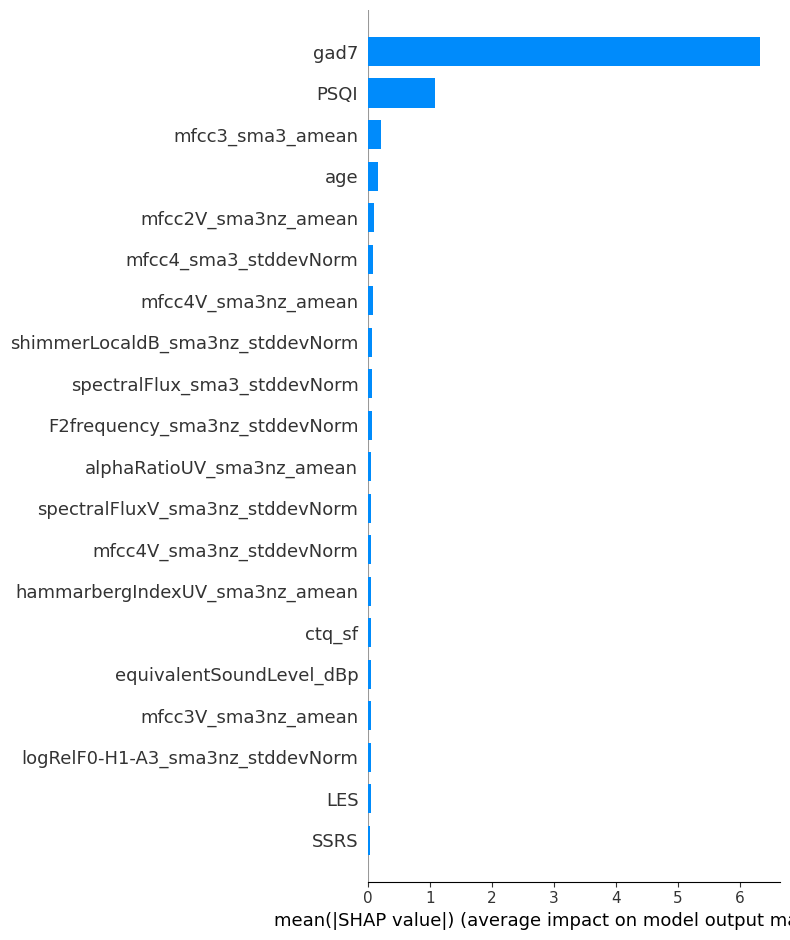

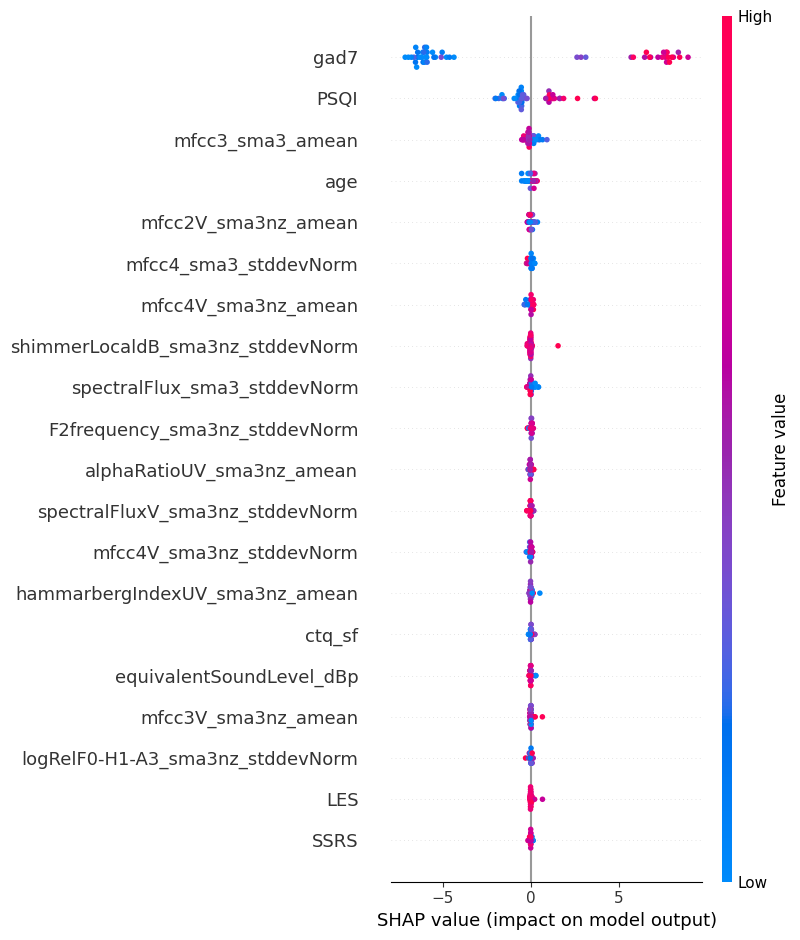

In [36]:
# Out-of-fold SHAP for the combined Clinical + Acoustic Random Forest
import numpy as np
import shap
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor

X_combined = model_df[CLINICAL_ACOUSTIC]
y = model_df["phq9"]

kf = KFold(n_splits=10, shuffle=True, random_state=SEED)   # same scheme as the rest of the pipeline

# Container for the held-out SHAP values, aligned to X_combined's rows
oof_shap = np.zeros(X_combined.shape)

for train_idx, test_idx in kf.split(X_combined):
    X_tr, X_te = X_combined.iloc[train_idx], X_combined.iloc[test_idx]
    y_tr = y.iloc[train_idx]

    rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_tr, y_tr)
    explainer = shap.TreeExplainer(rf)
    oof_shap[test_idx] = explainer.shap_values(X_te)       # explain only the unseen rows

# Same plots as full-data cells, but on out-of-fold SHAP values
shap.summary_plot(oof_shap, X_combined, plot_type="bar", max_display=20)  # global ranking (top 20)
shap.summary_plot(oof_shap, X_combined, max_display=20)                   # beeswarm: direction + magnitude



===== Clinical + Acoustic SHAP by category (corrected, additive) =====
                 mean_abs_shap_category  n_features
gad7                             6.3336           1
PSQI                             0.8257           1
Spectral                         0.6531          33
age                              0.2327           1
Formants                         0.1479          18
Voice quality                    0.1176          10
Timing/Pauses                    0.0660           6
Loudness/Energy                  0.0523           3
ctq_sf                           0.0468           1
SSRS                             0.0332           1
LES                              0.0309           1
Pitch                            0.0306           2
gender                           0.0087           1
education_years                  0.0016           1


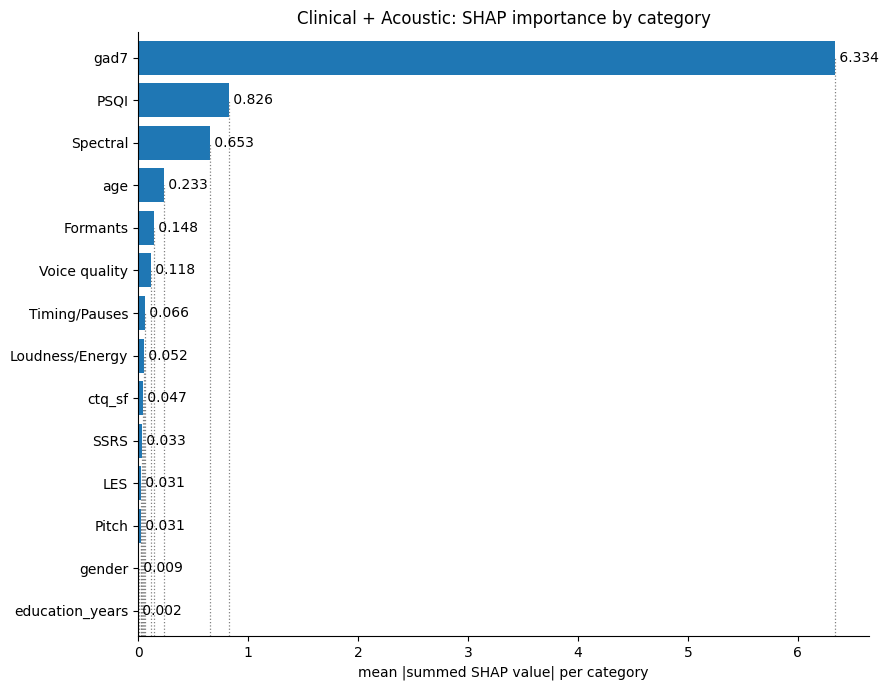

In [37]:
# SHAP for Clinical + Acoustic (combined), aggregated by category, reuses helpers from a previous cell
tbl_clinac = shap_by_category("Clinical + Acoustic", model_df[clinical + acoustic], y)


In [38]:
# ===== Full SHAP log for the acoustic Random Forest model =====
import numpy as np, pandas as pd, shap
from sklearn.ensemble import RandomForestRegressor

# --- Rebuild the acoustic feature matrix (self-contained) ---
X_acoustic = model_df[ACOUSTIC]
y = model_df["phq9"]

# --- Fit + SHAP (named shap_acoustic so it won't be overwritten by other cells) ---
rf_acoustic   = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_acoustic, y)
explainer     = shap.TreeExplainer(rf_acoustic)
shap_acoustic = explainer.shap_values(X_acoustic)          # shape: (52 subjects, 88 features)
base_value    = explainer.expected_value                    # model's mean prediction
base_value = float(np.ravel(base_value)[0])   # array([9.4]) -> 9.4, and a plain float is fine too


# --- 1. FULL per-subject x per-feature SHAP matrix ---
shap_full = pd.DataFrame(shap_acoustic, columns=X_acoustic.columns, index=model_df.index)
shap_full.insert(0, "subject_id", model_df["subject_key"].values)
shap_full.insert(1, "phq9_true", y.values)
shap_full.insert(2, "phq9_pred", rf_acoustic.predict(X_acoustic))
shap_full.to_csv(DATA_DIR / "shap_acoustic_full.csv", index=False)

# --- 2. GLOBAL per-feature summary (ranked) ---
summary = pd.DataFrame({
    "feature":       X_acoustic.columns,
    "mean_abs_shap": np.abs(shap_acoustic).mean(axis=0),   # magnitude of influence
    "mean_shap":     shap_acoustic.mean(axis=0),           # average signed direction
    "std_shap":      shap_acoustic.std(axis=0),            # how much it varies across subjects
})
# attach categories if you defined categorize() earlier
if "categories" in dir():
    summary["category"] = summary["feature"].map(categories)
summary = summary.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
summary.insert(0, "rank", summary.index + 1)
summary.to_csv(DATA_DIR / "shap_acoustic_summary.csv", index=False)

# --- 3. Readable log to console ---
print(f"Model base value (mean prediction): {base_value:.3f}")
print(f"SHAP matrix: {shap_full.shape[0]} subjects x {X_acoustic.shape[1]} features\n")
print("Top 15 acoustic features by mean |SHAP|:")
print(summary.head(15).to_string(index=False))
print(f"\nSaved:\n  {DATA_DIR / 'shap_acoustic_full.csv'}  (full matrix)"
      f"\n  {DATA_DIR / 'shap_acoustic_summary.csv'}  (ranked summary)")


Model base value (mean prediction): 9.361
SHAP matrix: 52 subjects x 72 features

Top 15 acoustic features by mean |SHAP|:
 rank                          feature  mean_abs_shap  mean_shap  std_shap        category
    1       spectralFluxV_sma3nz_amean       1.780232  -0.049581  1.942076        Spectral
    2      logRelF0-H1-A3_sma3nz_amean       0.768437   0.005813  0.943376   Voice quality
    3          spectralFlux_sma3_amean       0.698579  -0.025832  0.791791        Spectral
    4 shimmerLocaldB_sma3nz_stddevNorm       0.559463   0.029156  0.769637   Voice quality
    5       HNRdBACF_sma3nz_stddevNorm       0.512726   0.000709  0.609997   Voice quality
    6    alphaRatioV_sma3nz_stddevNorm       0.508361   0.004033  0.669418        Spectral
    7      spectralFluxUV_sma3nz_amean       0.290187  -0.001663  0.319284        Spectral
    8         equivalentSoundLevel_dBp       0.268565  -0.083604  0.278408 Loudness/Energy
    9         mfcc3V_sma3nz_stddevNorm       0.236315   0.

In [39]:
# ===== Full-SHAP logger =====
import numpy as np, pandas as pd, shap
from sklearn.ensemble import RandomForestRegressor

def shap_log(name, X, y, category_map=None, top=15):
    """Fit an RF, compute SHAP, and write a full matrix + ranked summary for feature set `name`."""
    rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X, y)
    explainer  = shap.TreeExplainer(rf)
    shap_vals  = explainer.shap_values(X)
    base_value = float(np.ravel(explainer.expected_value)[0])   # scalar-safe

    # 1. Full per-subject x per-feature matrix
    full = pd.DataFrame(shap_vals, columns=X.columns, index=model_df.index)
    full.insert(0, "subject_id", model_df["subject_key"].values)
    full.insert(1, "phq9_true", y.values)
    full.insert(2, "phq9_pred", rf.predict(X))
    full.to_csv(DATA_DIR / f"shap_{name}_full.csv", index=False)

    # 2. Ranked global summary
    summary = pd.DataFrame({
        "feature":       X.columns,
        "mean_abs_shap": np.abs(shap_vals).mean(axis=0),
        "mean_shap":     shap_vals.mean(axis=0),
        "std_shap":      shap_vals.std(axis=0),
    })
    if category_map is not None:
        summary["category"] = summary["feature"].map(category_map)
    summary = summary.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    summary.insert(0, "rank", summary.index + 1)
    summary.to_csv(DATA_DIR / f"shap_{name}_summary.csv", index=False)

    # 3. Console log
    print(f"\n===== {name.upper()} =====")
    print(f"Base value (mean prediction): {base_value:.3f}")
    print(f"Matrix: {full.shape[0]} subjects x {X.shape[1]} features")
    assert np.allclose(base_value + shap_vals.sum(axis=1), rf.predict(X))   # consistency check
    print(summary.head(top).to_string(index=False))
    return summary

# --- Feature-set definitions ---
demo     = DEMO
psych    = PSYCH
clinical = CLINICAL
acoustic = ACOUSTIC
y = model_df["phq9"]

feature_sets = {
    "demo":              demo,
    "psych":             psych,
    "clinical":          clinical,
    "acoustic":          acoustic,
    "demo_acoustic":     demo + acoustic,
    "clinical_acoustic": clinical + acoustic,   # fully combined (96 features)
}

shap_summaries = {}
for name, cols in feature_sets.items():
    top = len(cols) if len(cols) <= 8 else 15   # show all for small sets, top-15 for big ones
    shap_summaries[name] = shap_log(name, model_df[cols], y, top=top)




===== DEMO =====
Base value (mean prediction): 9.361
Matrix: 52 subjects x 3 features
 rank         feature  mean_abs_shap  mean_shap  std_shap
    1 education_years       3.871771  -0.269664  4.919850
    2             age       2.799167   0.421085  3.501527
    3          gender       1.164202   0.037080  1.621306

===== PSYCH =====
Base value (mean prediction): 9.361
Matrix: 52 subjects x 5 features
 rank feature  mean_abs_shap  mean_shap  std_shap
    1    gad7       6.162667   0.046226  6.423438
    2    PSQI       1.300007  -0.105590  1.463368
    3    SSRS       0.608835  -0.165759  0.741697
    4  ctq_sf       0.303969   0.027830  0.398613
    5     LES       0.228075   0.065562  0.296667

===== CLINICAL =====
Base value (mean prediction): 9.361
Matrix: 52 subjects x 8 features
 rank         feature  mean_abs_shap  mean_shap  std_shap
    1            gad7       6.143921   0.107596  6.397007
    2            PSQI       1.223258  -0.093542  1.366580
    3            SSRS       

In [ ]:
# Consolidated interpretability export (MDI + SHAP + permutation), matching the individual cells
import numpy as np, pandas as pd, shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

feature_sets = {
    "Demographics":          DEMO,
    "Psych":                 PSYCH,
    "Clinical":              CLINICAL,
    "Acoustic":              ACOUSTIC,
    "Demographics+Acoustic": DEMO + ACOUSTIC,
    "Clinical+Acoustic":     CLINICAL + ACOUSTIC,
}

records = []
for sname, cols in feature_sets.items():
    X = model_df[cols]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
    rf = RandomForestRegressor(n_estimators=100, random_state=SEED).fit(X_train, y_train)

    shap_vals = shap.TreeExplainer(rf).shap_values(X_test)
    perm = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=SEED, scoring="r2")

    df = pd.DataFrame({
        "model":        sname,
        "feature":      cols,
        "category":     [categorize(c) for c in cols],
        "mdi":          rf.feature_importances_,
        "shap_abs":     np.abs(shap_vals).mean(axis=0),
        "shap_signed":  shap_vals.mean(axis=0),
        "perm_mean":    perm.importances_mean,
        "perm_sd":      perm.importances_std,
    })
    df = df.sort_values("shap_abs", ascending=False).reset_index(drop=True)
    df.insert(2, "rank_by_shap", df.index + 1)
    records.append(df)

interp = pd.concat(records, ignore_index=True).round(4)
interp.to_csv(DATA_DIR / "interpretability_all.csv", index=False)
print(f"Exported {len(interp)} feature-rows across {len(feature_sets)} models.")
print(interp.groupby("model").head(3).to_string(index=False))

Exported 243 feature-rows across 6 models.
                model                      feature  rank_by_shap      category    mdi  shap_abs  shap_signed  perm_mean  perm_sd
         Demographics              education_years             1  Demographics 0.3989    4.9548       3.1506     1.0183   0.4917
         Demographics                          age             2  Demographics 0.5102    2.9176       0.6893     0.2671   0.2574
         Demographics                       gender             3  Demographics 0.0909    0.8821      -0.8821     0.0495   0.0764
                Psych                         gad7             1      Clinical 0.7754    6.9441       1.9800     0.9066   0.3405
                Psych                         PSQI             2      Clinical 0.1322    1.0825       0.1432     0.0683   0.0358
                Psych                         SSRS             3      Clinical 0.0442    1.0674      -0.1187    -0.0148   0.0242
             Clinical                         gad7    